In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/processed/gps_movement_features.csv"
)

df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (24730077, 20)


,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,month,is_weekend,previous_latitude,previous_longitude,previous_timestamp,distance_km,time_difference_seconds,speed_kmh,location,time_spent_minutes
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,10,False,NaN,NaN,NaN,0.000000,0.0,0.000000,39.9847_116.3184,0.000000
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,10,False,39.984702,116.318417,2008-10-23 02:53:04,0.002812,6.0,1.687092,39.9847_116.3184,0.100000
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,10,False,39.984683,116.318450,2008-10-23 02:53:10,0.002812,5.0,2.024341,39.9847_116.3184,0.083333
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,10,False,39.984686,116.318417,2008-10-23 02:53:15,0.002726,5.0,1.962995,39.9847_116.3184,0.083333
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,10,False,39.984688,116.318385,2008-10-23 02:53:20,0.010395,5.0,7.484055,39.9847_116.3183,0.083333


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24730077 entries, 0 to 24730076
Data columns (total 20 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   user_id                  int64         
 1   latitude                 float64       
 2   longitude                float64       
 3   altitude                 float64       
 4   date                     str           
 5   time                     str           
 6   timestamp                datetime64[us]
 7   hour                     int64         
 8   day                      int64         
 9   weekday                  str           
 10  month                    int64         
 11  is_weekend               bool          
 12  previous_latitude        float64       
 13  previous_longitude       float64       
 14  previous_timestamp       str           
 15  distance_km              float64       
 16  time_difference_seconds  float64       
 17  speed_kmh                float64    

In [4]:
df.describe()

,user_id,latitude,longitude,altitude,timestamp,hour,day,month,previous_latitude,previous_longitude,distance_km,time_difference_seconds,speed_kmh,time_spent_minutes
count,2.473008e+07,2.473008e+07,2.473008e+07,2.473008e+07,24730077,2.473008e+07,2.473008e+07,2.473008e+07,2.472990e+07,2.472990e+07,2.473008e+07,2.473008e+07,2.473008e+07,2.473008e+07
mean,7.631616e+01,3.897398e+01,1.123364e+02,5.157554e+02,2009-07-02 04:02:11.343842,8.948305e+00,1.538126e+01,6.409894e+00,3.897398e+01,1.123364e+02,4.998135e-02,1.195478e+02,1.683122e+01,1.992463e+00
min,0.000000e+00,1.044024e+00,-1.799696e+02,-3.264760e+04,2000-01-01 23:12:19,0.000000e+00,1.000000e+00,1.000000e+00,1.044024e+00,-1.799696e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.500000e+01,3.990620e+01,1.163066e+02,7.985222e+01,2008-11-08 16:50:41,4.000000e+00,8.000000e+00,4.000000e+00,3.990620e+01,1.163066e+02,6.824609e-04,1.000000e+00,9.746284e-01,1.666667e-02
50%,6.500000e+01,3.997494e+01,1.163346e+02,1.476000e+02,2009-03-19 00:35:32,9.000000e+00,1.500000e+01,6.000000e+00,3.997494e+01,1.163346e+02,2.922116e-03,2.000000e+00,4.174930e+00,3.333333e-02
75%,1.310000e+02,3.999853e+01,1.164196e+02,2.198000e+02,2009-08-02 02:00:12,1.300000e+01,2.300000e+01,9.000000e+00,3.999853e+01,1.164196e+02,1.081858e-02,5.000000e+00,2.354677e+01,8.333333e-02
max,1.810000e+02,6.475199e+01,1.799969e+02,1.075033e+05,2012-07-27 08:31:20,2.300000e+01,3.100000e+01,1.200000e+01,6.475199e+01,1.799969e+02,1.112816e+04,2.296048e+08,2.000000e+02,3.826746e+06
std,5.666740e+01,4.081035e+00,2.725846e+01,2.308366e+03,NaN,6.065610e+00,8.862665e+00,3.303757e+00,4.081041e+00,2.725856e+01,1.082392e+01,6.573511e+04,2.597834e+01,1.095585e+03


In [5]:
hourly_movement = (
    df.groupby("hour")
    .size()
    .reset_index(name="movement_count")
)

hourly_movement

,hour,movement_count
0,0,1385506
1,1,1508233
2,2,1341107
3,3,1261584
4,4,1259943
5,5,1250449
6,6,1335771
7,7,1401434
8,8,1465316
9,9,1713703


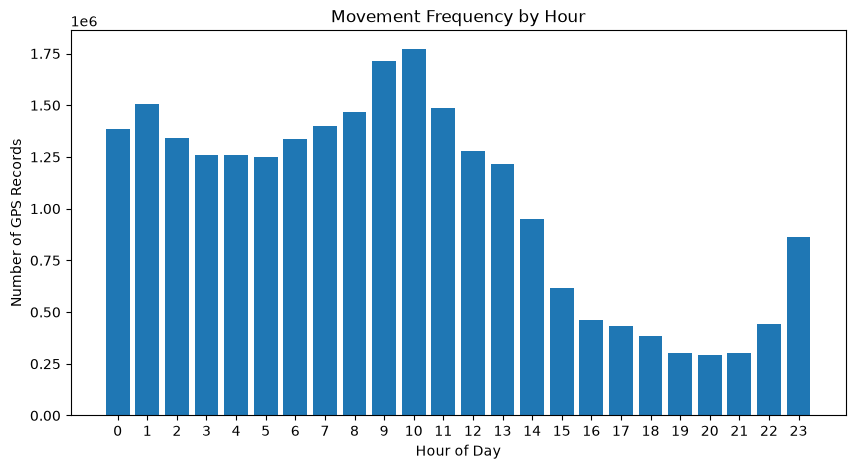

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(
    hourly_movement["hour"],
    hourly_movement["movement_count"]
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of GPS Records")
plt.title("Movement Frequency by Hour")
plt.xticks(range(24))

plt.show()

In [7]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_movement = (
    df.groupby("weekday")
    .size()
    .reindex(weekday_order)
)

weekday_movement

weekday
Monday       3216523
Tuesday      3028942
Wednesday    3290146
Thursday     3454077
Friday       3725418
Saturday     4364880
Sunday       3650091
dtype: int64

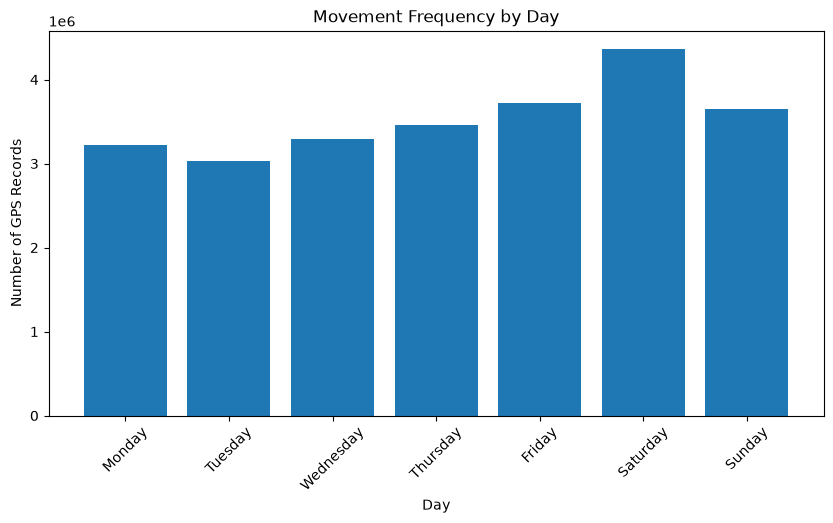

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_movement.index,
    weekday_movement.values
)

plt.xlabel("Day")
plt.ylabel("Number of GPS Records")
plt.title("Movement Frequency by Day")

plt.xticks(rotation=45)

plt.show()

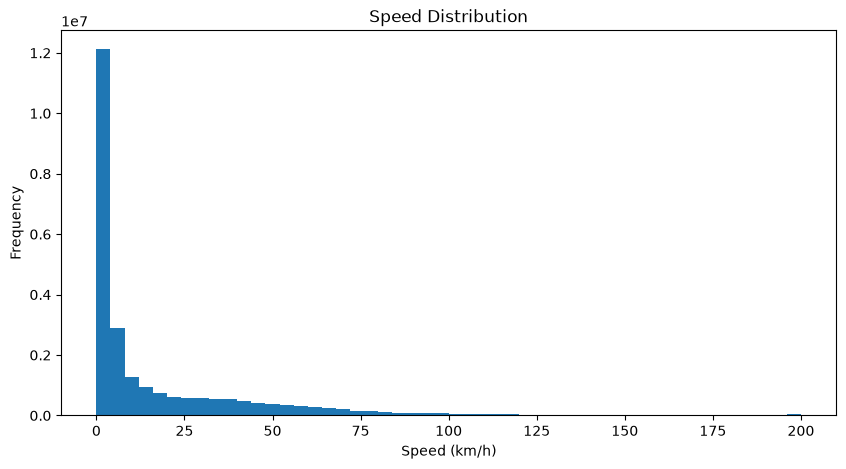

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["speed_kmh"],
    bins=50
)

plt.xlabel("Speed (km/h)")
plt.ylabel("Frequency")
plt.title("Speed Distribution")

plt.show()

In [10]:
print("Average speed:",
      df["speed_kmh"].mean())

print("Maximum speed:",
      df["speed_kmh"].max())

print("Median speed:",
      df["speed_kmh"].median())

Average speed: 16.83122439827291
Maximum speed: 200.0
Median speed: 4.174930132151154


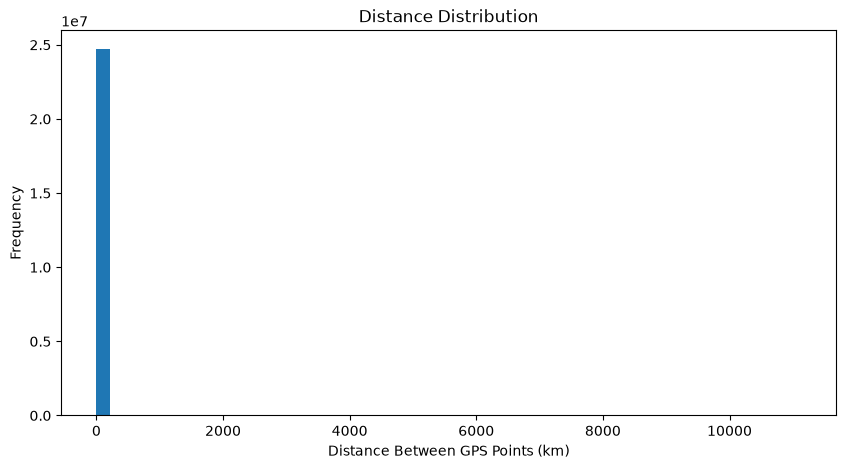

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["distance_km"],
    bins=50
)

plt.xlabel("Distance Between GPS Points (km)")
plt.ylabel("Frequency")
plt.title("Distance Distribution")

plt.show()

In [12]:
df["date_only"] = df["timestamp"].dt.date

daily_distance = (
    df.groupby(
        ["user_id", "date_only"]
    )["distance_km"]
    .sum()
    .reset_index()
)

daily_distance.head()

,user_id,date_only,distance_km
0,0,2008-10-23,9.883460
1,0,2008-10-24,0.830362
2,0,2008-10-26,17.030892
3,0,2008-10-27,1.055035
4,0,2008-10-28,6.581623


In [13]:
daily_distance["distance_km"].describe()

count     11147.000000
mean        110.885678
std        3829.146364
min           0.000000
25%           4.865806
50%          13.709729
75%          29.535447
max      399905.793288
Name: distance_km, dtype: float64

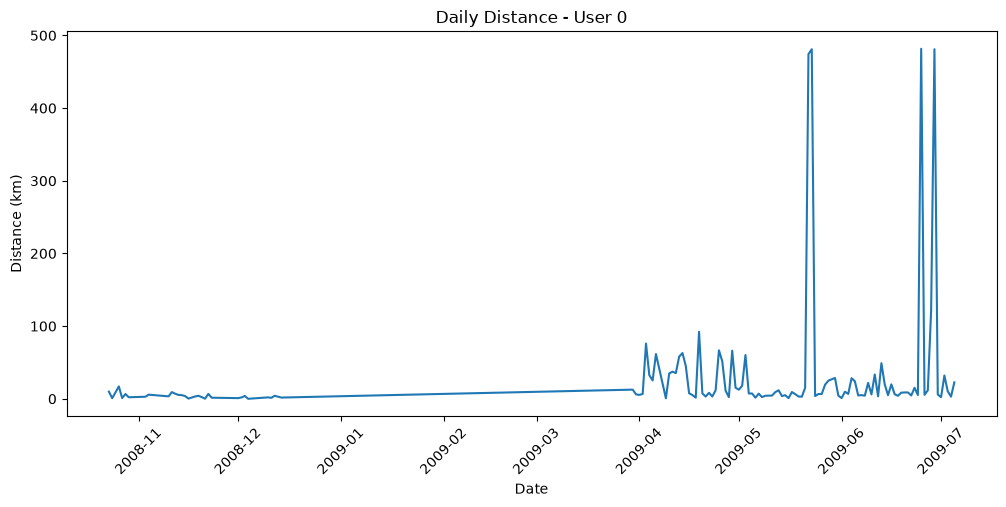

In [14]:
sample_user = df["user_id"].iloc[0]

user_daily_distance = daily_distance[
    daily_distance["user_id"] == sample_user
]

plt.figure(figsize=(12, 5))

plt.plot(
    user_daily_distance["date_only"],
    user_daily_distance["distance_km"]
)

plt.xlabel("Date")
plt.ylabel("Distance (km)")
plt.title(
    f"Daily Distance - User {sample_user}"
)

plt.xticks(rotation=45)

plt.show()

In [15]:
location_frequency = (
    df.groupby(
        ["latitude", "longitude"]
    )
    .size()
    .reset_index(
        name="visit_frequency"
    )
)

location_frequency = (
    location_frequency
    .sort_values(
        "visit_frequency",
        ascending=False
    )
)

location_frequency.head(10)

,latitude,longitude,visit_frequency
15150114,39.988683,116.451660,769
5861668,39.911720,116.453515,485
15133649,39.988547,116.451445,445
1185290,31.304490,121.088595,386
1184855,31.304295,121.088377,349
1184952,31.304363,121.088333,319
1184853,31.304293,121.088377,286
12756093,39.980073,116.448355,286
3183072,39.697240,119.329418,249
15810480,39.992317,116.413435,232


In [16]:
top_locations = location_frequency.head(10)

display(top_locations)

,latitude,longitude,visit_frequency
15150114,39.988683,116.451660,769
5861668,39.911720,116.453515,485
15133649,39.988547,116.451445,445
1185290,31.304490,121.088595,386
1184855,31.304295,121.088377,349
1184952,31.304363,121.088333,319
1184853,31.304293,121.088377,286
12756093,39.980073,116.448355,286
3183072,39.697240,119.329418,249
15810480,39.992317,116.413435,232


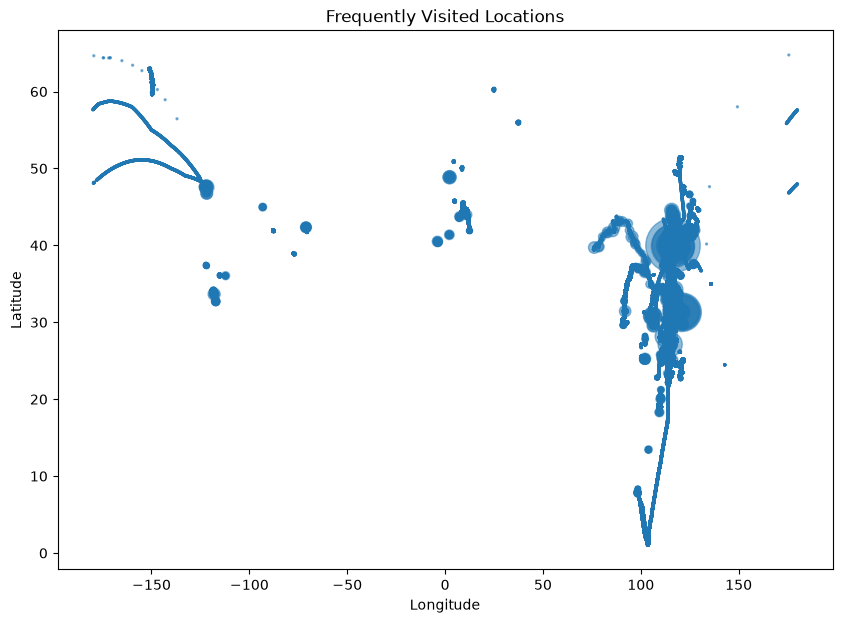

In [17]:
plt.figure(figsize=(10, 7))

plt.scatter(
    location_frequency["longitude"],
    location_frequency["latitude"],
    s=location_frequency["visit_frequency"] * 2,
    alpha=0.5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Frequently Visited Locations")

plt.show()

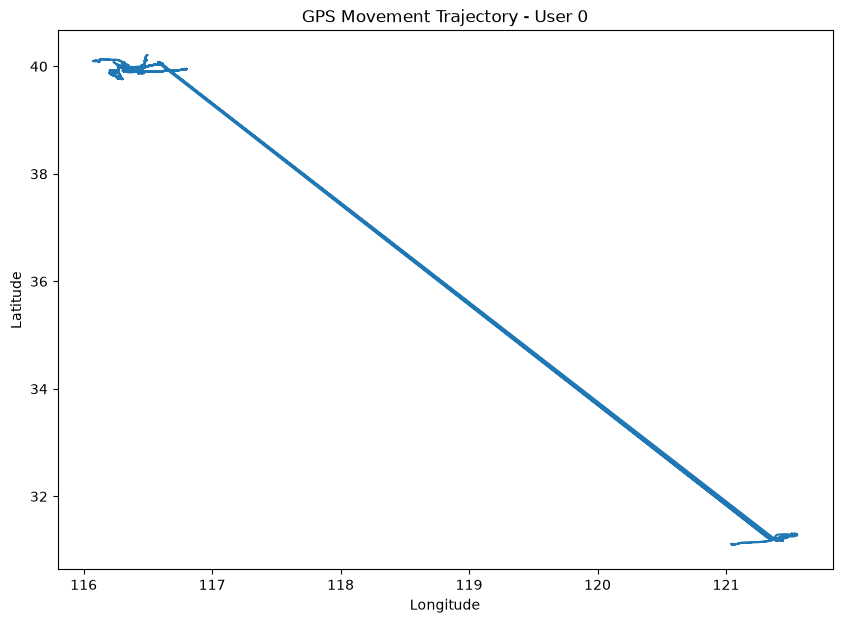

In [18]:
sample_user = df["user_id"].iloc[0]

user_trajectory = df[
    df["user_id"] == sample_user
].sort_values("timestamp")

plt.figure(figsize=(10, 7))

plt.plot(
    user_trajectory["longitude"],
    user_trajectory["latitude"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"GPS Movement Trajectory - User {sample_user}"
)

plt.show()

In [19]:
most_active_hours = (
    hourly_movement
    .sort_values(
        "movement_count",
        ascending=False
    )
    .head(10)
)

most_active_hours

,hour,movement_count
10,10,1772781
9,9,1713703
1,1,1508233
11,11,1485865
8,8,1465316
7,7,1401434
0,0,1385506
2,2,1341107
6,6,1335771
12,12,1276389


In [20]:
speed_by_hour = (
    df.groupby("hour")["speed_kmh"]
    .mean()
    .reset_index()
)

speed_by_hour

,hour,speed_kmh
0,0,16.745444
1,1,17.372582
2,2,17.663649
3,3,16.259462
4,4,15.159673
5,5,15.456134
6,6,14.287248
7,7,16.256361
8,8,17.461079
9,9,16.163056


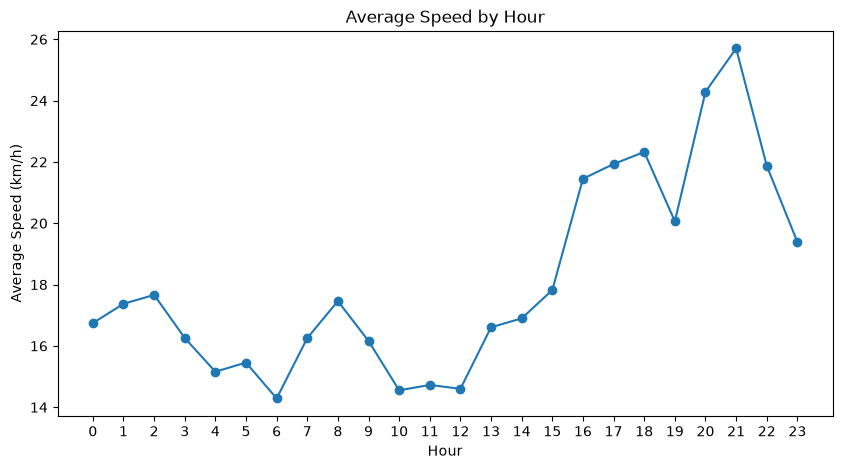

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    speed_by_hour["hour"],
    speed_by_hour["speed_kmh"],
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Average Speed (km/h)")
plt.title("Average Speed by Hour")
plt.xticks(range(24))

plt.show()

In [22]:
weekend_analysis = (
    df.groupby("is_weekend")
    .agg(
        total_records=("user_id", "count"),
        average_speed=("speed_kmh", "mean"),
        total_distance=("distance_km", "sum")
    )
)

weekend_analysis

,total_records,average_speed,total_distance
is_weekend,,,
False,16715106,16.847807,952976.699211
True,8014971,16.796642,283065.949703


In [23]:
user_distance = (
    df.groupby("user_id")["distance_km"]
    .sum()
    .sort_values(
        ascending=False
    )
)

user_distance.head(10)

user_id
62     430368.072903
163    144271.174984
153     95191.910114
128     60865.214409
140     51601.892808
10      40194.363229
144     33173.443475
142     32719.444378
84      28437.003989
25      27007.413852
Name: distance_km, dtype: float64

In [24]:
user_speed = (
    df.groupby("user_id")["speed_kmh"]
    .mean()
    .sort_values(
        ascending=False
    )
)

user_speed.head(10)

user_id
124    48.135545
10     42.718179
148    41.420841
49     40.774123
180    39.548673
135    37.485859
99     34.460401
144    34.303534
31     34.030919
12     34.019098
Name: speed_kmh, dtype: float64

In [25]:
eda_summary = {
    "total_records": len(df),
    "unique_users": df["user_id"].nunique(),
    "average_speed_kmh": df["speed_kmh"].mean(),
    "maximum_speed_kmh": df["speed_kmh"].max(),
    "total_distance_km": df["distance_km"].sum(),
    "most_active_hour": hourly_movement.loc[
        hourly_movement["movement_count"].idxmax(),
        "hour"
    ],
    "most_active_weekday": weekday_movement.idxmax()
}

eda_summary

{'total_records': 24730077,
 'unique_users': 182,
 'average_speed_kmh': np.float64(16.83122439827291),
 'maximum_speed_kmh': np.float64(200.0),
 'total_distance_km': np.float64(1236042.6489139476),
 'most_active_hour': np.int64(10),
 'most_active_weekday': 'Saturday'}

In [26]:
import os

os.makedirs(
    "../data/processed/eda",
    exist_ok=True
)

In [27]:
hourly_movement.to_csv(
    "../data/processed/eda/hourly_movement.csv",
    index=False
)

In [28]:
weekday_movement.to_csv(
    "../data/processed/eda/weekday_movement.csv"
)

In [29]:
daily_distance.to_csv(
    "../data/processed/eda/daily_distance.csv",
    index=False
)

In [30]:
location_frequency.to_csv(
    "../data/processed/eda/location_frequency.csv",
    index=False
)

In [31]:
print("EDA completed successfully!")

print("\nMost active hour:")
print(eda_summary["most_active_hour"])

print("\nMost active weekday:")
print(eda_summary["most_active_weekday"])

print("\nAverage speed:")
print(eda_summary["average_speed_kmh"])

print("\nTotal distance:")
print(eda_summary["total_distance_km"])

EDA completed successfully!

Most active hour:
10

Most active weekday:
Saturday

Average speed:
16.83122439827291

Total distance:
1236042.6489139476
